**STEP 1 ,2 and 3**

In [4]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df= yf.download(["SPY","TLT","SHY","GLD","DBO"],start="2018-01-01", end="2022-12-30")

/tmp/ipykernel_1022/2281189463.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df= yf.download(["SPY","TLT","SHY","GLD","DBO"],start="2018-01-01", end="2022-12-30")
[*********************100%***********************]  5 of 5 completed


In [6]:
df.head()

Price          Close                                                    High  \
Ticker           DBO         GLD        SHY         SPY        TLT       DBO   
Date                                                                           
2018-01-02  8.636581  125.150002  69.636971  236.562134  98.705643  8.662009   
2018-01-03  8.823045  124.820000  69.636971  238.058472  99.177612  8.823045   
2018-01-04  8.839996  125.459999  69.603775  239.061859  99.161865  8.865423   
2018-01-05  8.797618  125.330002  69.603775  240.654953  98.878677  8.814569   
2018-01-08  8.848471  125.309998  69.603775  241.095062  98.815788  8.856946   

Price                                                     ...      Open  \
Ticker             GLD        SHY         SPY        TLT  ...       DBO   
Date                                                      ...             
2018-01-02  125.180000  69.661893  236.597348  99.507939  ...  8.645057   
2018-01-03  125.089996  69.653584  238.208112  99.264135  ...  8.704388   
2018-01-04  125.849998  69.620394  239.545967  99.232659  ...  8.823045   
2018-01-05  125.480003  69.612085  240.778162  99.248362  ...  8.772191   
2018-01-08  125.320000  69.620394  241.253486  99.130414  ...  8.806094   

Price                                                     Volume            \
Ticker             GLD        SHY         SPY        TLT     DBO       GLD   
Date                                                                         
2018-01-02  124.660004  69.661893  235.743586  99.492205  155000  11762500   
2018-01-03  125.050003  69.628661  236.729413  99.106825  216000   7904300   
2018-01-04  124.889999  69.595465  238.701015  98.831511  184600   7329700   
2018-01-05  124.930000  69.595465  239.853999  99.004530  307700   5739900   
2018-01-08  125.199997  69.620394  240.558147  99.098951  183400   3566700   

Price                                    
Ticker          SHY       SPY       TLT  
Date                                     
2018-01-02  1786000  86655700  16238200  
2018-01-03  1040900  90070400   8605100  
2018-01-04   955400  80636400   9217900  
2018-01-05   850600  83524000  10915400  
2018-01-08   597700  57319200   8850600  

[5 rows x 25 columns]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2018-01-02 to 2022-12-29
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, DBO)   1258 non-null   float64
 1   (Close, GLD)   1258 non-null   float64
 2   (Close, SHY)   1258 non-null   float64
 3   (Close, SPY)   1258 non-null   float64
 4   (Close, TLT)   1258 non-null   float64
 5   (High, DBO)    1258 non-null   float64
 6   (High, GLD)    1258 non-null   float64
 7   (High, SHY)    1258 non-null   float64
 8   (High, SPY)    1258 non-null   float64
 9   (High, TLT)    1258 non-null   float64
 10  (Low, DBO)     1258 non-null   float64
 11  (Low, GLD)     1258 non-null   float64
 12  (Low, SHY)     1258 non-null   float64
 13  (Low, SPY)     1258 non-null   float64
 14  (Low, TLT)     1258 non-null   float64
 15  (Open, DBO)    1258 non-null   float64
 16  (Open, GLD)    1258 non-null   float64
 17  (Open, SHY)    1258 non-null   flo

In [8]:
df_close = df["Close"]
df_log_returns = np.log(df_close / df_close.shift(1)).dropna()

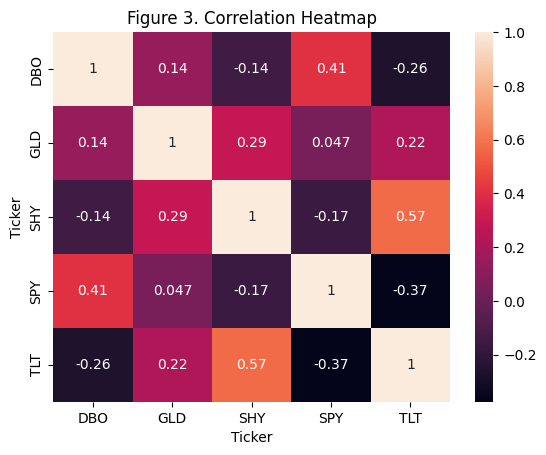

In [9]:
plt.title("Figure 3. Correlation Heatmap"); sns.heatmap(rets.corr(), annot=True); plt.show()

In [10]:
normalized_df = (df_close / df_close.iloc[0]) * 100

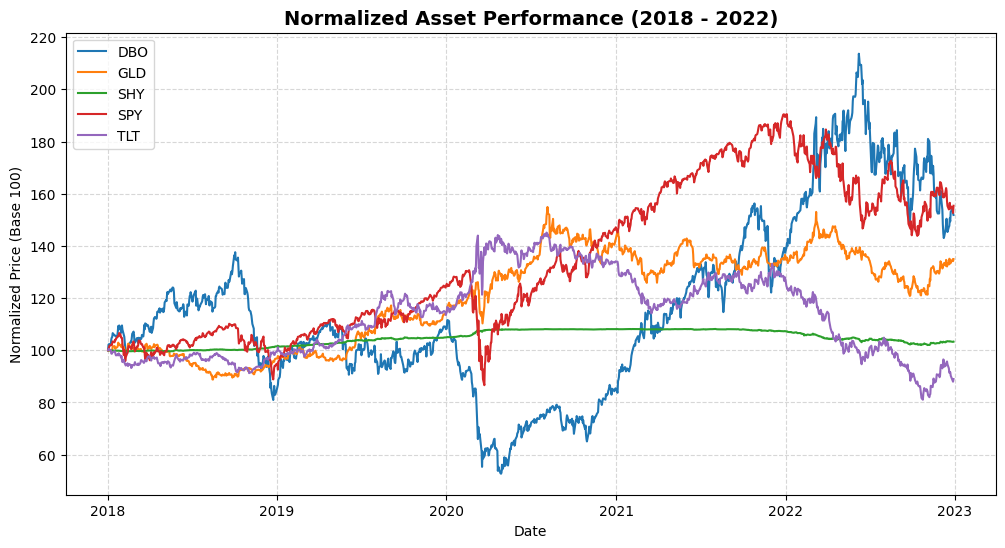

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(normalized_df.index, normalized_df)
plt.legend(normalized_df.columns, loc='upper left')
plt.title('Normalized Asset Performance (2018 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Base 100)')
plt.grid(True, linestyle='--', alpha=0.5)

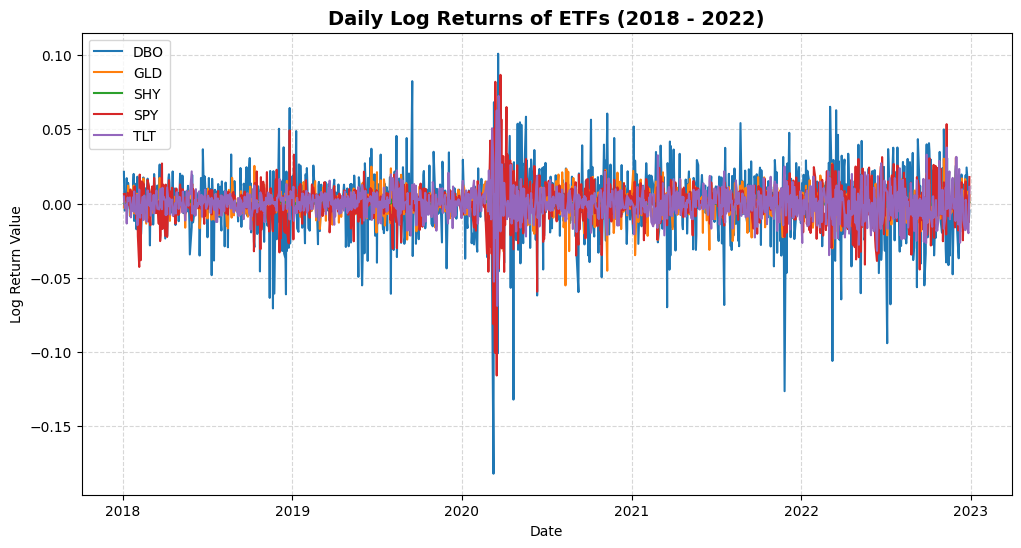

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_log_returns.index, df_log_returns)
plt.legend(df_log_returns.columns, loc='upper left')


plt.title('Daily Log Returns of ETFs (2018 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Log Return Value')
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

# Create an empty list to store the results for each ETF
stat_results = []

for col in df_log_returns.columns:
    # 1. Run Augmented Dickey-Fuller (ADF) Test
    # Null Hypothesis (H0): The series has a unit root (Non-Stationary)
    adf_stat, adf_p, _, _, adf_critical, _ = adfuller(df_log_returns[col])

    # 2. Run Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
    # Null Hypothesis (H0): The series is Trend/Mean Stationary
    kpss_stat, kpss_p, _, kpss_critical = kpss(df_log_returns[col], regression='c', nlags='auto')

    # Store the p-values and decisions
    stat_results.append({
        'ETF Ticker': col,
        'ADF p-value': round(adf_p, 5),
        'ADF Null (H0)': 'Reject (Stationary)' if adf_p < 0.05 else 'Fail to Reject',
        'KPSS p-value': round(kpss_p, 5),
        'KPSS Null (H0)': 'Fail to Reject (Stationary)' if kpss_p > 0.05 else 'Reject'
    })

# Convert the results list into a clean DataFrame to view them
df_test_summary = pd.DataFrame(stat_results)
print(df_test_summary)

  ETF Ticker  ADF p-value        ADF Null (H0)  KPSS p-value  \
0        DBO          0.0  Reject (Stationary)       0.10000   
1        GLD          0.0  Reject (Stationary)       0.10000   
2        SHY          0.0  Reject (Stationary)       0.01000   
3        SPY          0.0  Reject (Stationary)       0.10000   
4        TLT          0.0  Reject (Stationary)       0.03817   

                KPSS Null (H0)  
0  Fail to Reject (Stationary)  
1  Fail to Reject (Stationary)  
2                       Reject  
3  Fail to Reject (Stationary)  
4                       Reject  


/tmp/ipykernel_2166/144885011.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_critical = kpss(df_log_returns[col], regression='c', nlags='auto')
/tmp/ipykernel_2166/144885011.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_critical = kpss(df_log_returns[col], regression='c', nlags='auto')
/tmp/ipykernel_2166/144885011.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_critical = kpss(df_log_returns[col], regression='c', nlags='auto')
/tmp/ipykernel_2166/144885011.py:14: InterpolationWarning: The test statistic is outside of the rang

In [13]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.1 MB/s eta 0:00:00


[*******************   40%                       ]  2 of 5 completed

[*********************100%***********************]  5 of 5 completed



 PROCESSING GAF-CNN PIPELINE FOR ETF: SPY 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[SPY] In-Sample Calibration Accuracy: 75.18%
[SPY] Out-of-Sample Test Evaluation Accuracy: 39.67%


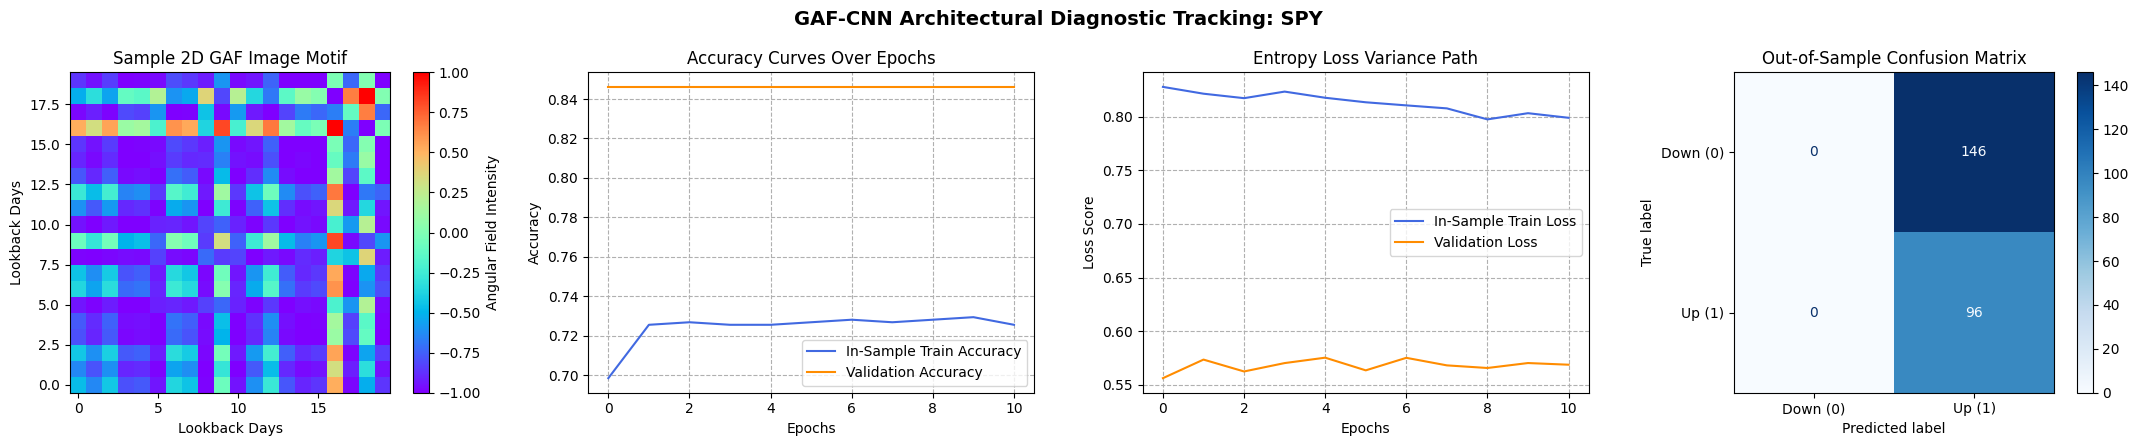


 PROCESSING GAF-CNN PIPELINE FOR ETF: TLT 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[TLT] In-Sample Calibration Accuracy: 67.87%
[TLT] Out-of-Sample Test Evaluation Accuracy: 36.78%


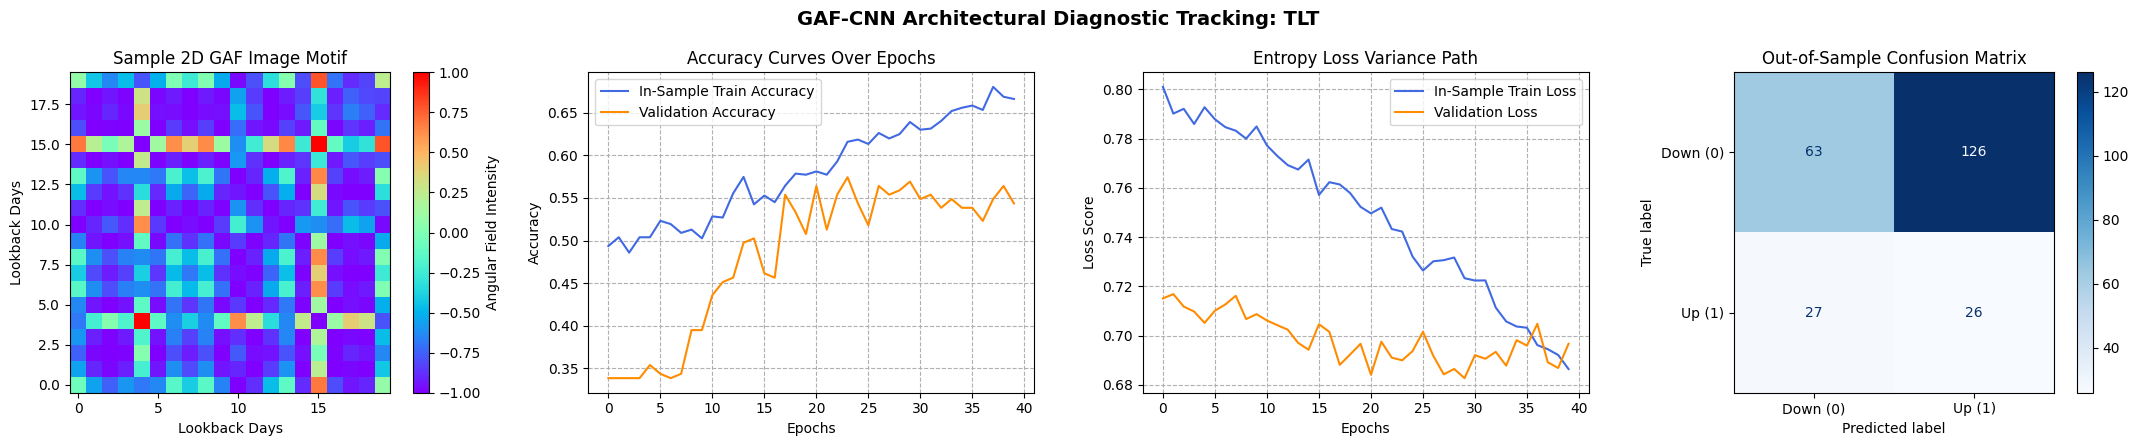


 PROCESSING GAF-CNN PIPELINE FOR ETF: SHY 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[SHY] In-Sample Calibration Accuracy: 67.04%
[SHY] Out-of-Sample Test Evaluation Accuracy: 30.17%


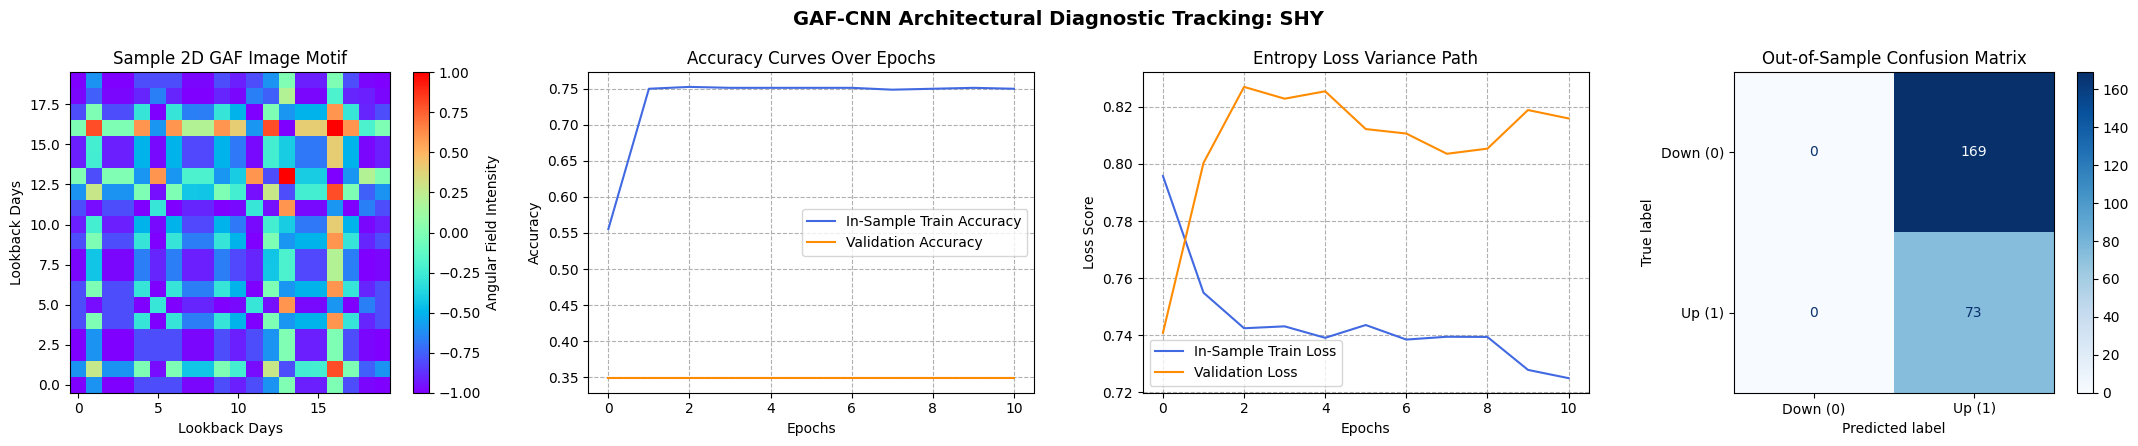


 PROCESSING GAF-CNN PIPELINE FOR ETF: GLD 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[GLD] In-Sample Calibration Accuracy: 59.53%
[GLD] Out-of-Sample Test Evaluation Accuracy: 50.83%


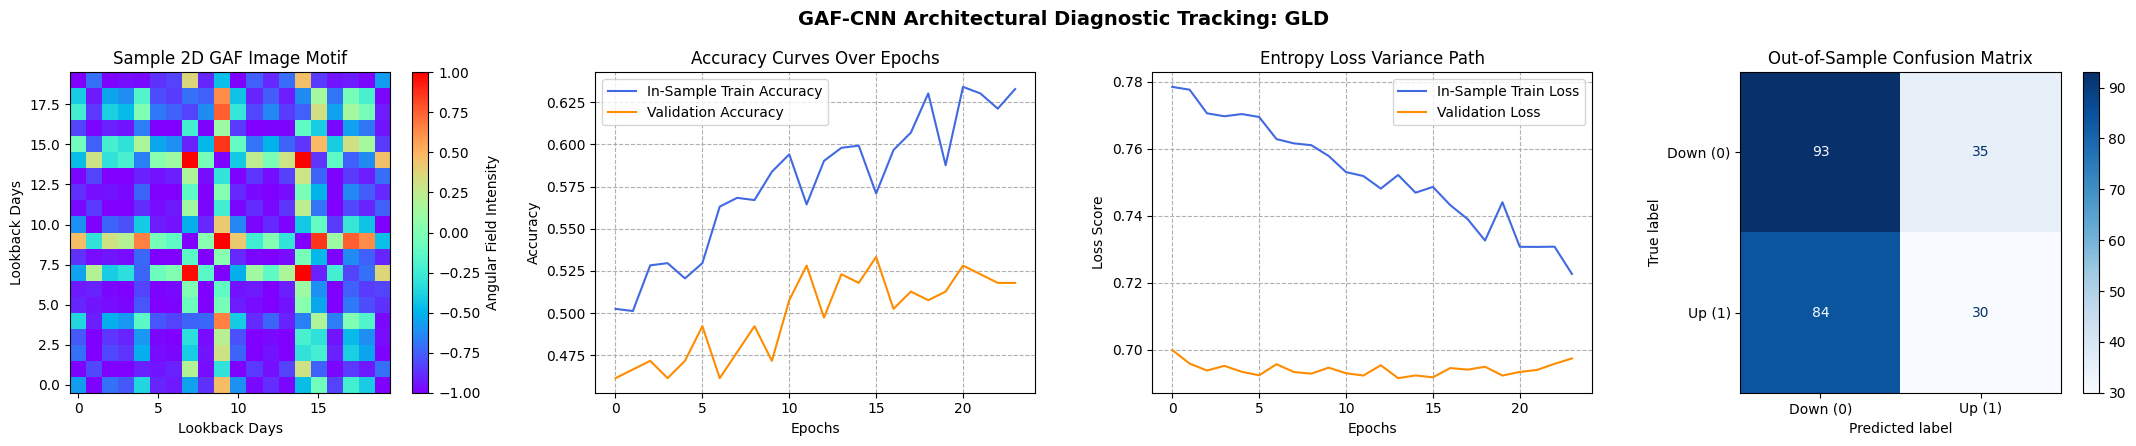


 PROCESSING GAF-CNN PIPELINE FOR ETF: DBO 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[DBO] In-Sample Calibration Accuracy: 69.21%
[DBO] Out-of-Sample Test Evaluation Accuracy: 46.69%


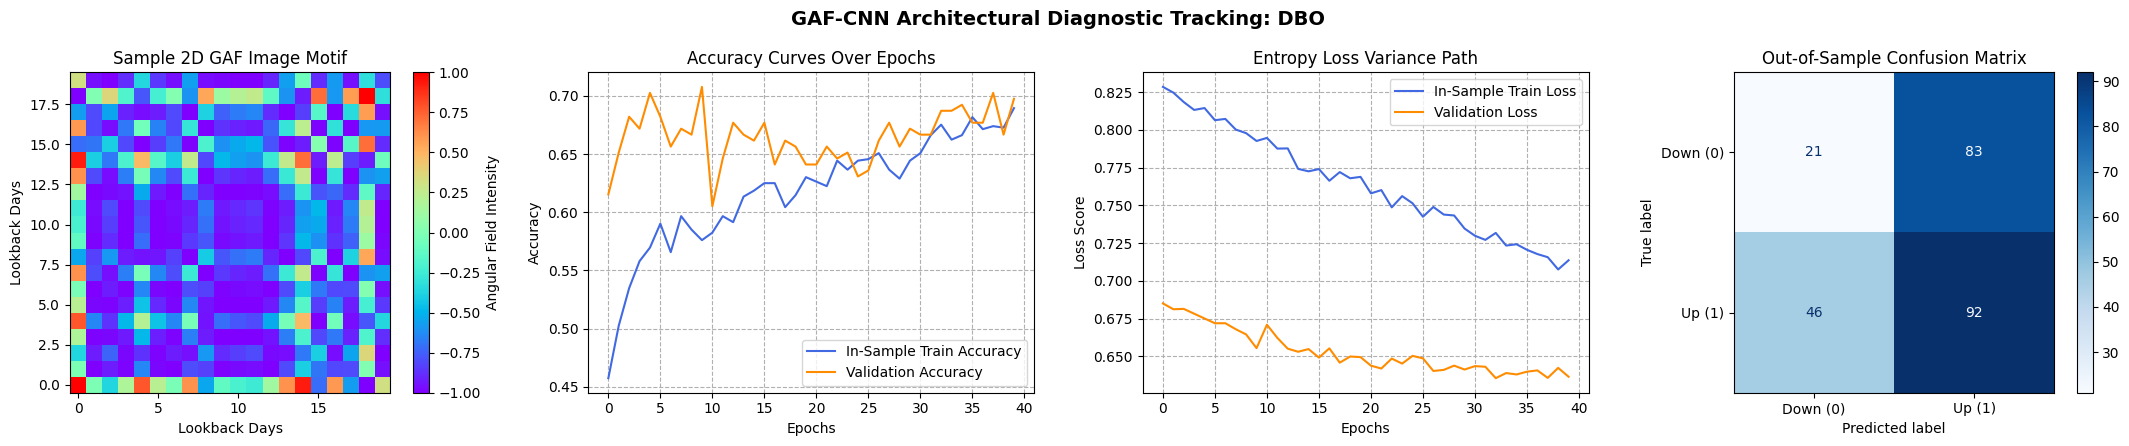


             FINAL GAF-CNN SUMMARY EVALUATION MATRIX                  
Asset Class Ticker (ETF) In-Sample Acc       Out-of-Sample Acc   
-----------------------------------------------------------------
SPY                      75.18%              39.67%              
TLT                      67.87%              36.78%              
SHY                      67.04%              30.17%              
GLD                      59.53%              50.83%              
DBO                      69.21%              46.69%              


In [ ]:
import os
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Ensure the pyts library is installed for GAF transformations
# If missing, run: !pip install pyts
from pyts.image import GramianAngularField

# =====================================================================
# 1. ENVIRONMENT CONFIGURATION & REPRODUCIBILITY
# =====================================================================
tf.keras.backend.clear_session()
tf.random.set_seed(1234)
np.random.seed(1234)

# Define Core Problem Constants
assets = ["SPY", "TLT", "SHY", "GLD", "DBO"]
lookback_window = 20   # 20 days historical window to map motifs
forward_horizon = 25   # 25 days forward return prediction horizon

print("Downloading asset historical daily data matrix via Yahoo Finance...")
df = yf.download(assets, start="2018-01-01", end="2022-12-30", auto_adjust=True)
close_df = df['Close'].dropna()

# Map raw prices to simple percentage daily returns (stationarity transformation)
returns_df = close_df.pct_change().dropna()

# Dictionary to hold the cross-asset experimental summary values
cnn_performance_summary = {}

# Initialize Gramian Angular Field transformer using Summation formulation (GASF)
gaf = GramianAngularField(image_size=lookback_window, method='summation')

# =====================================================================
# 2. RUNTIME INDEPENDENT CNN PIPELINE ENGINE
# =====================================================================
for asset in assets:
    print("\n" + "="*65)
    print(f" PROCESSING GAF-CNN PIPELINE FOR ETF: {asset} ")
    print("="*65)

    asset_returns = returns_df[asset].values
    total_length = len(asset_returns)

    X_asset_images = []
    y_asset_labels = []

    # Generate rolling overlapping feature chunks chronologically
    for i in range(total_length - lookback_window - forward_horizon + 1):
        # Features: Extract the stationary daily return sequence block
        window_returns = asset_returns[i : i + lookback_window]

        # Targets: Compute the compounded geometric true return over the next 25 days
        forward_start_idx = i + lookback_window
        forward_end_idx = forward_start_idx + forward_horizon
        forward_return = np.prod(1 + asset_returns[forward_start_idx : forward_end_idx]) - 1

        # Map performance to directional binary flag (1 = UP, 0 = DOWN)
        label = 1 if forward_return > 0 else 0

        # Apply GAF mapping: Reshape vector to matrix structure (1, lookback)
        window_reshaped = window_returns.reshape(1, -1)
        gaf_matrix = gaf.fit_transform(window_reshaped)[0]

        X_asset_images.append(gaf_matrix)
        y_asset_labels.append(label)

    X_asset = np.array(X_asset_images)
    y_asset = np.array(y_asset_labels)

    # Expand channel shape for Keras Conv2D input requirements: (Samples, Height, Width, Channels)
    X_asset = np.expand_dims(X_asset, axis=-1)

    # -----------------------------------------------------------------
    # CHRONOLOGICAL TIME-SERIES DATA SPLIT (No Shuffling Allowed)
    # -----------------------------------------------------------------
    test_size = int(0.20 * len(y_asset))
    split_idx = len(y_asset) - test_size

    X_train, X_test = X_asset[:split_idx], X_asset[split_idx:]
    y_train, y_test = y_asset[:split_idx], y_asset[split_idx:]

    # Compute class scaling configurations to negate natural background asset drift bias
    mean_y_train = np.mean(y_train) if np.mean(y_train) > 0 else 0.5
    class_weight_setting = {0: (mean_y_train / 0.5) * 1.2, 1: 1.0}

    # -----------------------------------------------------------------
    # MODEL GENERATION & COMPILATION
    # -----------------------------------------------------------------
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(lookback_window, lookback_window, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.3),  # Regularization to prevent training over-fitting
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    # Execute training path calibration
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        class_weight=class_weight_setting
    )

    # -----------------------------------------------------------------
    # EVALUATION & STORAGE METRICS MATRIX
    # -----------------------------------------------------------------
    in_prob = model.predict(X_train, verbose=0)
    in_pred = np.where(in_prob > 0.50, 1, 0).flatten()
    in_sample_accuracy = accuracy_score(y_train, in_pred)

    out_prob = model.predict(X_test, verbose=0)
    out_pred = np.where(out_prob > 0.50, 1, 0).flatten()
    out_sample_accuracy = accuracy_score(y_test, out_pred)

    cnn_performance_summary[asset] = {
        "In_Sample": in_sample_accuracy,
        "Out_of_Sample": out_sample_accuracy,
        "Confusion_Matrix": confusion_matrix(y_test, out_pred)
    }

    print(f"[{asset}] In-Sample Calibration Accuracy: {in_sample_accuracy:.2%}")
    print(f"[{asset}] Out-of-Sample Test Evaluation Accuracy: {out_sample_accuracy:.2%}")

    # -----------------------------------------------------------------
    # VISUAL COMPILING: GENERATING MULTI-PLOT BOARDS WITH GAF HEATMAP
    # -----------------------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
    fig.suptitle(f"GAF-CNN Architectural Diagnostic Tracking: {asset}", fontsize=14, fontweight='bold')

    # Plot 1: STANDALONE GAF IMAGE REPRESENTATION
    # Squeezing the channel dimension from (20, 20, 1) to (20, 20) to plot as a 2D grid
    sample_gaf_matrix = X_train[0, :, :, 0]
    im = axes[0].imshow(sample_gaf_matrix, cmap='rainbow', origin='lower')
    axes[0].set_title(f"Sample 2D GAF Image Motif")
    axes[0].set_xlabel("Lookback Days")
    axes[0].set_ylabel("Lookback Days")
    fig.colorbar(im, ax=axes[0], label="Angular Field Intensity")

    # Plot 2: Accuracy Diagnostics Curve
    axes[1].plot(history.history['accuracy'], label='In-Sample Train Accuracy', color='royalblue')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
    axes[1].set_title("Accuracy Curves Over Epochs")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, linestyle='--')

    # Plot 3: Overfitting Divergence Loss Curve
    axes[1].grid(True, linestyle='--')
    axes[2].plot(history.history['loss'], label='In-Sample Train Loss', color='royalblue')
    axes[2].plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
    axes[2].set_title("Entropy Loss Variance Path")
    axes[2].set_xlabel("Epochs")
    axes[2].set_ylabel("Loss Score")
    axes[2].legend()
    axes[2].grid(True, linestyle='--')

    # Plot 4: Out-of-Sample Confusion Matrix Grid
    cm = cnn_performance_summary[asset]["Confusion_Matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
    disp.plot(ax=axes[3], cmap='Blues', values_format='d')
    axes[3].set_title("Out-of-Sample Confusion Matrix")

    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. FINAL COMPARATIVE PRESENTATION GRID
# =====================================================================
print("\n" + "="*65)
print("             FINAL GAF-CNN SUMMARY EVALUATION MATRIX                  ")
print("="*65)
print(f"{'Asset Class Ticker (ETF)':<25}{'In-Sample Acc':<20}{'Out-of-Sample Acc':<20}")
print("-" * 65)
for asset in assets:
    res = cnn_performance_summary[asset]
    in_str = f"{res['In_Sample']:.2%}"
    out_str = f"{res['Out_of_Sample']:.2%}"
    print(f"{asset:<25}{in_str:<20}{out_str:<20}")
print("="*65)

[**********************80%*************          ]  4 of 5 completed

[*********************100%***********************]  5 of 5 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 PROCESSING MULTINEURAL (MLP) PIPELINE FOR ETF: SPY 
[SPY] Multineural In-Sample Accuracy: 75.38%
[SPY] Multineural Out-of-Sample Accuracy: 41.67%


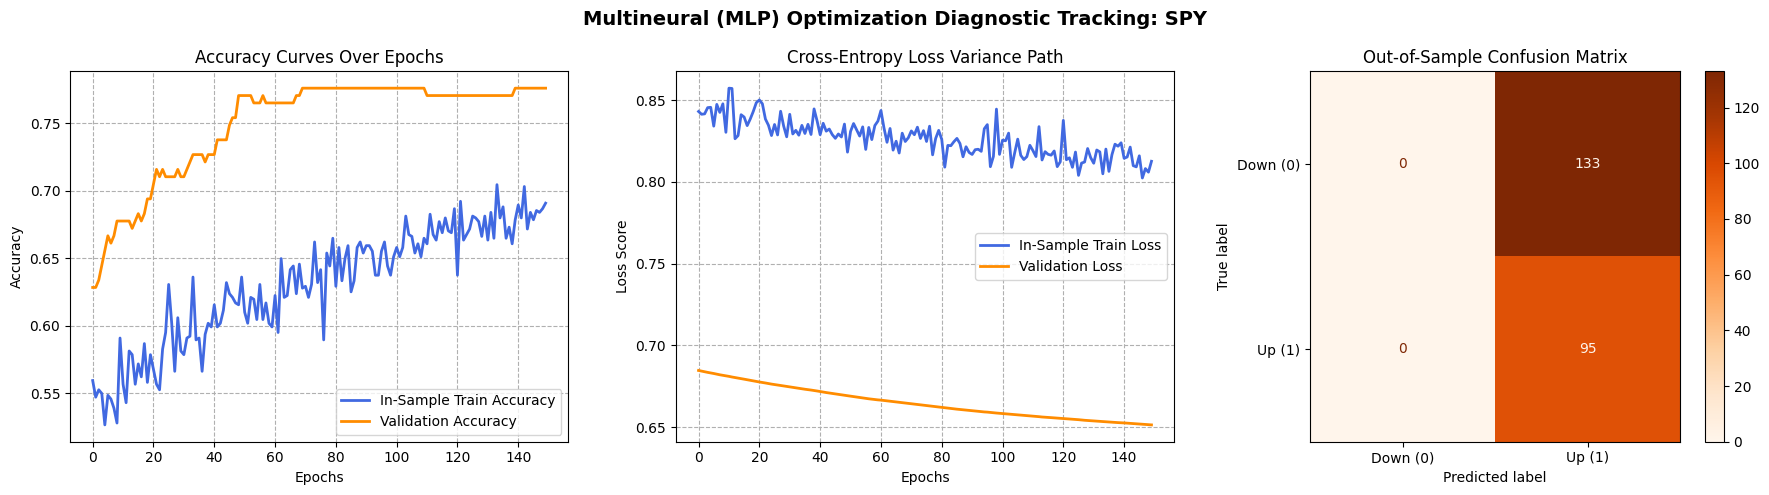


 PROCESSING MULTINEURAL (MLP) PIPELINE FOR ETF: TLT 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[TLT] Multineural In-Sample Accuracy: 54.60%
[TLT] Multineural Out-of-Sample Accuracy: 25.44%


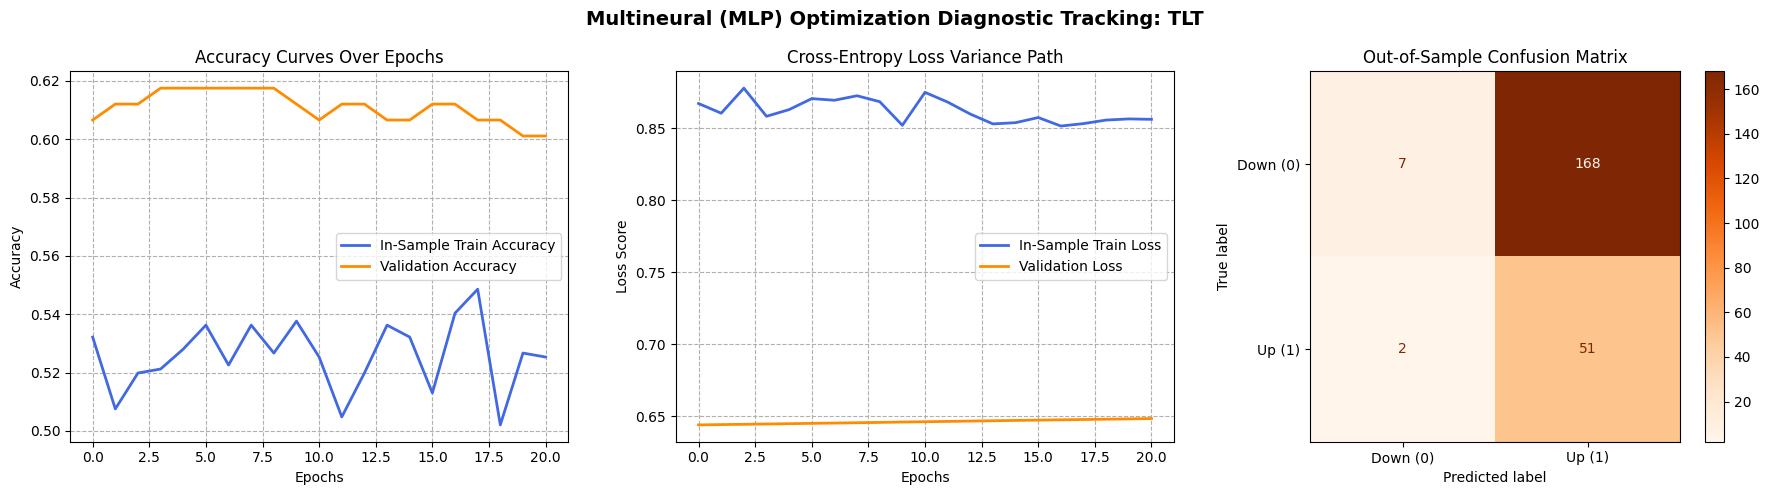


 PROCESSING MULTINEURAL (MLP) PIPELINE FOR ETF: SHY 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[SHY] Multineural In-Sample Accuracy: 59.30%
[SHY] Multineural Out-of-Sample Accuracy: 67.98%


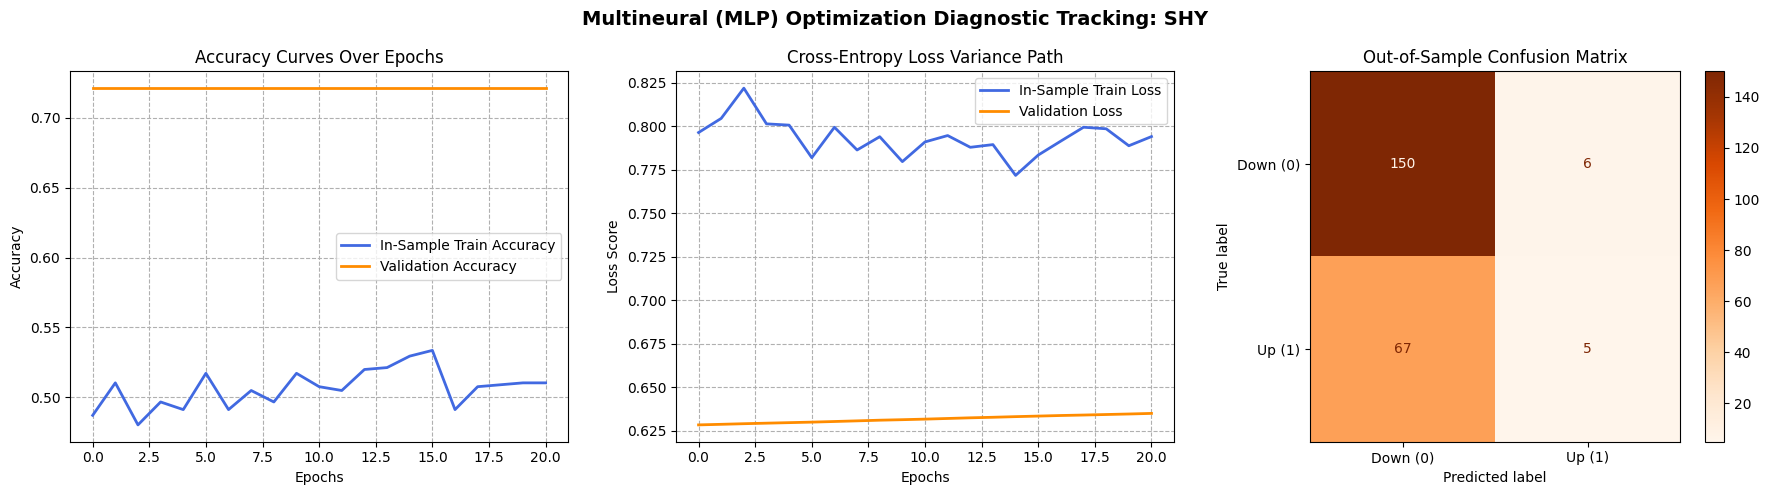


 PROCESSING MULTINEURAL (MLP) PIPELINE FOR ETF: GLD 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[GLD] Multineural In-Sample Accuracy: 55.58%
[GLD] Multineural Out-of-Sample Accuracy: 55.26%


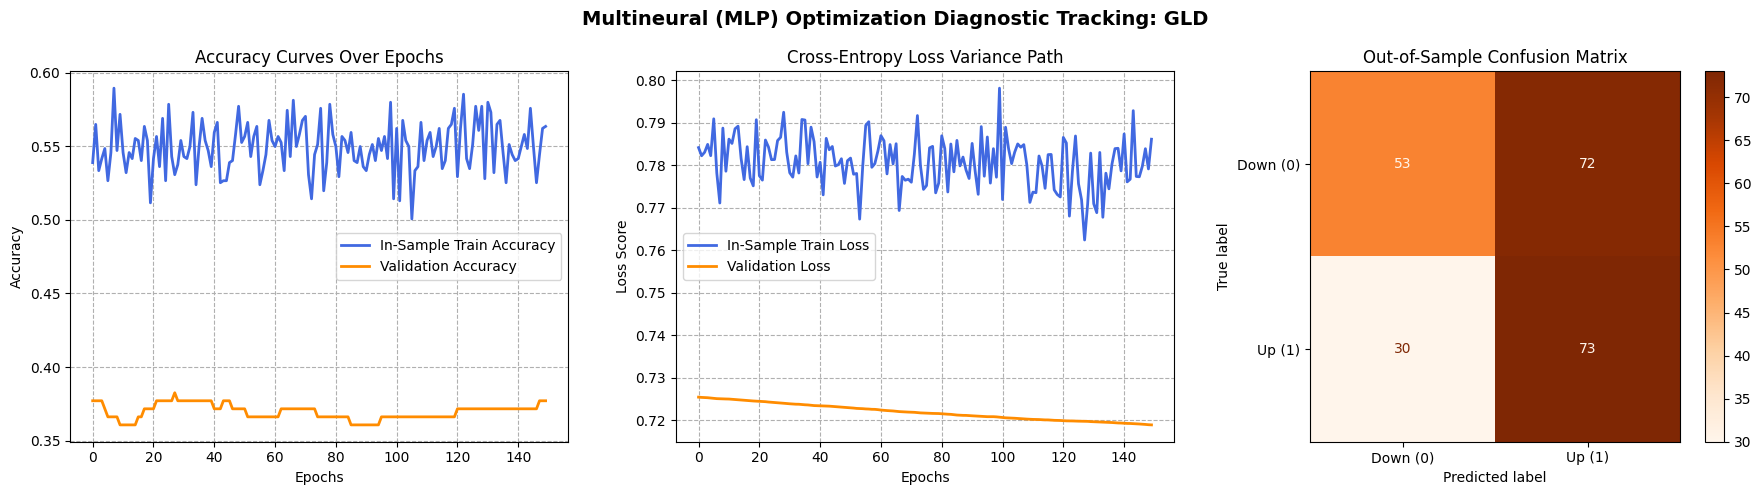


 PROCESSING MULTINEURAL (MLP) PIPELINE FOR ETF: DBO 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[DBO] Multineural In-Sample Accuracy: 56.46%
[DBO] Multineural Out-of-Sample Accuracy: 52.19%


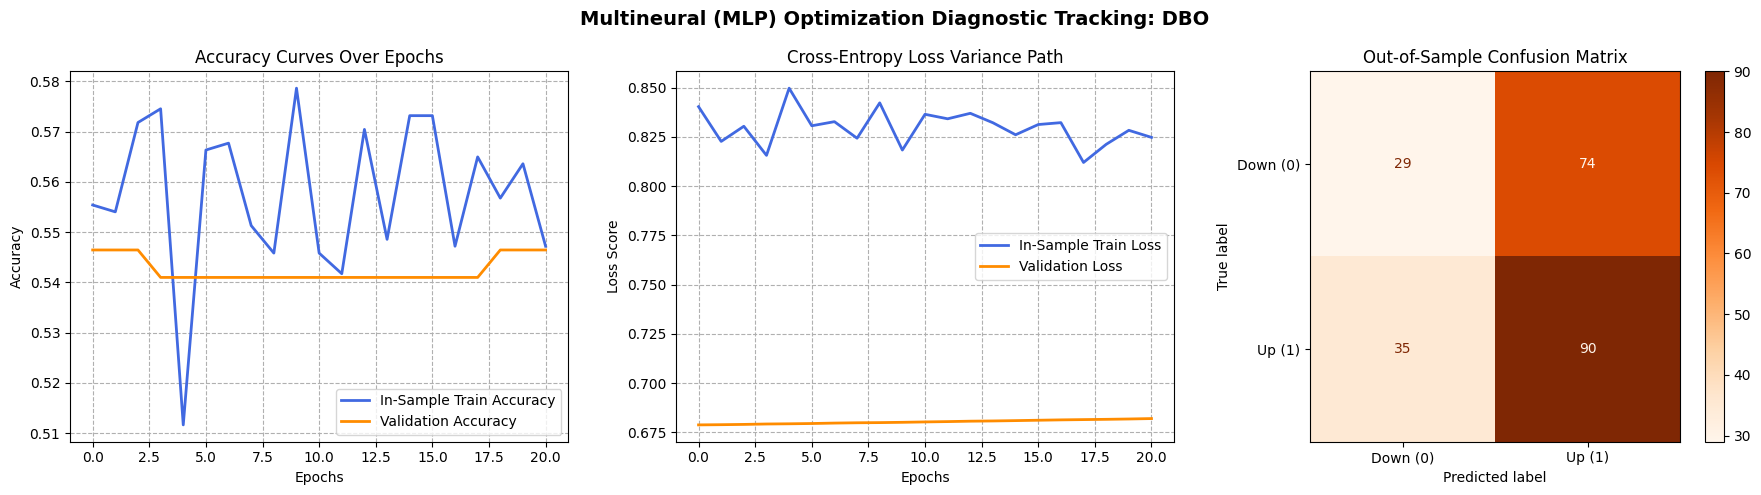


             FINAL MULTINEURAL REPORT SUMMARY MATRIX                  
Asset Class Ticker (ETF) In-Sample Acc       Out-of-Sample Acc   
-----------------------------------------------------------------
SPY                      75.38%              41.67%              
TLT                      54.60%              25.44%              
SHY                      59.30%              67.98%              
GLD                      55.58%              55.26%              
DBO                      56.46%              52.19%              


In [ ]:
import os
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# =====================================================================
# 1. ENVIRONMENT CONFIGURATION & REPRODUCIBILITY
# =====================================================================
tf.keras.backend.clear_session()
tf.random.set_seed(1234)
np.random.seed(1234)

# Define Core Matching Constants
assets = ["SPY", "TLT", "SHY", "GLD", "DBO"]
forward_horizon = 25   # 25 days forward horizon prediction target

# Define the 5 different historical feature lookback windows
feature_windows = [5, 10, 20, 60, 90]
max_lookback = max(feature_windows) # 90 days required to build the largest feature window

print("Downloading asset historical dataset universe via Yahoo Finance...")
df_raw = yf.download(assets, start="2018-01-01", end="2022-12-30", auto_adjust=True)
close_df = df_raw['Close'].dropna()

# Map raw prices to simple percentage daily returns (stationary sequence inputs)
returns_df = 100 * close_df.pct_change()
returns_df = returns_df.dropna()

# Dictionary to collect multi-asset MLP metric profiles
mlp_performance_summary = {}

# =====================================================================
# 2. RUNTIME INDEPENDENT MULTINEURAL PIPELINE ENGINE
# =====================================================================
for asset in assets:
    print("\n" + "="*65)
    print(f" PROCESSING MULTINEURAL (MLP) PIPELINE FOR ETF: {asset} ")
    print("="*65)

    asset_returns = returns_df[asset].values
    total_length = len(asset_returns)

    X_list, y_list = [], []

    # Slide across the timeline starting at max_lookback so the 90-day feature window can resolve
    for t in range(max_lookback, total_length - forward_horizon):

        # -----------------------------------------------------------------
        # FEATURE ENGINEERING: GENERATING THE 5 DISTINCT ROLLING WINDOWS
        # -----------------------------------------------------------------
        day_features = []
        for w in feature_windows:
            # Isolate the past window historical slice relative to current step t
            past_window = asset_returns[t - w : t]
            # Calculate the compounded return over that specific lookback block
            compounded_window_return = np.prod(1 + past_window / 100.0) - 1.0
            day_features.append(compounded_window_return)

        # Append the 5 multi-horizon rolling features as a flat 1D vector row for day t
        X_list.append(day_features)

        # Target (y): Compounded true performance return over the upcoming 25 trading days
        future_window = asset_returns[t : t + forward_horizon]
        cumulative_return = np.prod(1 + future_window / 100.0) - 1.0

        # Map to matching binary target directional space (1 = UP, 0 = DOWN)
        binary_label = 1 if cumulative_return > 0 else 0
        y_list.append(binary_label)

    X_raw = np.array(X_list)
    y_raw = np.array(y_list)

    # -----------------------------------------------------------------
    # CHRONOLOGICAL TIME-SERIES DATA SPLIT (Strictly No Shuffling)
    # -----------------------------------------------------------------
    # Dedicating the trailing 20% chunk of the matrix timeline to out-of-sample testing
    test_size = int(0.20 * len(y_raw))
    split_idx = len(y_raw) - test_size

    X_train_raw, X_test_raw = X_raw[:split_idx], X_raw[split_idx:]
    y_train, y_test = y_raw[:split_idx], y_raw[split_idx:]

    # Standardize input feature spaces to stabilize dense row backpropagation passes
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # Formulate Keras class weights to stabilize trends across structural regimes
    mean_y_train = np.mean(y_train) if np.mean(y_train) > 0 else 0.5
    class_weight_setting = {0: (mean_y_train / 0.5) * 1.2, 1: 1.0}

    # -----------------------------------------------------------------
    # MLP DEEP ARCHITECTURE SELECTION (Direct from your template)
    # -----------------------------------------------------------------
    act_fun = "relu"
    hp_units = 25
    hp_units_2 = 15
    hp_units_3 = 10
    n_dropout = 0.2
    hp_lr = 1e-5

    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(units=hp_units, activation=act_fun, input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dropout(n_dropout),
        tf.keras.layers.Dense(units=hp_units_2, activation=act_fun),
        tf.keras.layers.Dropout(n_dropout),
        tf.keras.layers.Dense(units=hp_units_3, activation=act_fun),
        tf.keras.layers.Dropout(n_dropout),
        tf.keras.layers.Dense(units=1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Template patience mapping
    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    # Execute Model Training
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        class_weight=class_weight_setting
    )

    # -----------------------------------------------------------------
    # IN-SAMPLE AND OUT-OF-SAMPLE PERFORMANCE EXTRACTION
    # -----------------------------------------------------------------
    # Calculate In-Sample Performance
    in_sample_probs = model.predict(X_train, verbose=0)
    in_sample_preds = np.where(in_sample_probs > 0.50, 1, 0).flatten()
    in_sample_acc = accuracy_score(y_train, in_sample_preds)

    # Calculate Out-of-Sample Performance
    out_sample_probs = model.predict(X_test, verbose=0)
    out_sample_preds = np.where(out_sample_probs > 0.50, 1, 0).flatten()
    out_sample_acc = accuracy_score(y_test, out_sample_preds)

    # Store results inside summary object
    mlp_performance_summary[asset] = {
        "In_Sample": in_sample_acc,
        "Out_of_Sample": out_sample_acc,
        "Confusion_Matrix": confusion_matrix(y_test, out_sample_preds)
    }

    print(f"[{asset}] Multineural In-Sample Accuracy: {in_sample_acc:.2%}")
    print(f"[{asset}] Multineural Out-of-Sample Accuracy: {out_sample_acc:.2%}")

    # -----------------------------------------------------------------
    # VISUAL COMPILING: MATCHING GRAPH GENERATION FORMAT
    # -----------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Multineural (MLP) Optimization Diagnostic Tracking: {asset}", fontsize=14, fontweight='bold')

    # Graph 1: MLP In-Sample vs Validation Accuracy Curves
    axes[0].plot(history.history['accuracy'], label='In-Sample Train Accuracy', color='royalblue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
    axes[0].set_title("Accuracy Curves Over Epochs")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, linestyle='--')

    # Graph 2: MLP In-Sample vs Validation Loss Curves
    axes[1].plot(history.history['loss'], label='In-Sample Train Loss', color='royalblue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
    axes[1].set_title("Cross-Entropy Loss Variance Path")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss Score")
    axes[1].legend()
    axes[1].grid(True, linestyle='--')

    # Graph 3: Out-of-Sample MLP Confusion Matrix Grid
    cm = mlp_performance_summary[asset]["Confusion_Matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
    disp.plot(ax=axes[2], cmap='Oranges', values_format='d')
    axes[2].set_title("Out-of-Sample Confusion Matrix")

    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. FINAL CLEAN CROSS-ASSET LOGICAL EVALUATION GRID
# =====================================================================
print("\n" + "="*65)
print("             FINAL MULTINEURAL REPORT SUMMARY MATRIX                  ")
print("="*65)
print(f"{'Asset Class Ticker (ETF)':<25}{'In-Sample Acc':<20}{'Out-of-Sample Acc':<20}")
print("-" * 65)
for asset in assets:
    res = mlp_performance_summary[asset]
    in_sample_str = f"{res['In_Sample']:.2%}"
    out_sample_str = f"{res['Out_of_Sample']:.2%}"
    print(f"{asset:<25}{in_sample_str:<20}{out_sample_str:<20}")
print("="*65)

# MScFE 642 — Deep Learning for Finance — GWP1
## Steps 4, 5 & 6 — Recurrent (LSTM) Models, Multi-Output Model, and Backtest

- The assignment defines **2018-01-01 → 2022-12-30 as the out-of-sample TEST period**. We therefore download a longer history (from 2010) so that training/validation can use data *before* 2018, leaving 2018–2022 untouched as a genuine hold-out. All five ETFs (SPY, TLT, SHY, GLD, DBO) have continuous data from 2010.
- Stationary representation: **daily log returns** (consistent with Steps 1–3 and the ADF results).
- Target: **25-trading-day-ahead cumulative log return**, `y_t = sum(r_{t+1} .. r_{t+25}) = log(P_{t+25}/P_t)`.
- Predictors per asset: the daily log return plus 10-day and 50-day trailing cumulative log returns, fed as a **30-step rolling window** (same window logic as Module 5 lessons).


In [ ]:
# ============================================================
# Imports & reproducibility
# ============================================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import tensorflow as tf
from keras import Sequential, Model
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

SEED = 1234
np.random.seed(SEED)
tf.random.set_seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:0.4f}")


In [ ]:
# ============================================================
# Global configuration
# ============================================================
TICKERS      = ["SPY", "TLT", "SHY", "GLD", "DBO"]   # 5 ETFs (groups of 1-2 may keep only 3)
DATA_START   = "2010-01-01"     # extended history for train/validation
DATA_END     = "2022-12-30"
TEST_START   = "2018-01-01"     # assignment-defined OOS test start
VAL_START    = "2016-01-01"     # validation = 2016-2017 ; train = everything before 2016

HORIZON      = 25     # predict 25-day-ahead cumulative return
WINDOW       = 30     # length of the input sequence fed to the LSTM
EPOCHS       = 100
BATCH        = 64
LR           = 1e-4
UNITS        = 50
DROPOUT      = 0.2


In [ ]:
# ============================================================
# Data download  (reuses the group's Step-1 loading logic)
# ============================================================
raw = yf.download(TICKERS, start=DATA_START, end=DATA_END, auto_adjust=True, progress=False)
close = raw["Close"][TICKERS].dropna(how="all")
log_ret = np.log(close / close.shift(1)).dropna()
print("Close shape:", close.shape, " Log-return shape:", log_ret.shape)
log_ret.head()


Close shape: (3271, 5)  Log-return shape: (3270, 5)


Ticker,SPY,TLT,SHY,GLD,DBO
Date,,,,,
2010-01-05,0.0026,0.0064,0.0012,-0.0009,0.0092
2010-01-06,0.0007,-0.0135,0.0001,0.0164,0.0123
2010-01-07,0.0042,0.0017,-0.0002,-0.0062,-0.0070
2010-01-08,0.0033,-0.0004,0.0010,0.0050,0.0049
2010-01-11,0.0014,-0.0055,0.0005,0.0132,-0.0056


In [ ]:
# ============================================================
# Feature engineering (per asset)
#   features : r_t , trailing 10-day cum log-ret , trailing 50-day cum log-ret
#   target   : 25-day-ahead cum log-ret  =  sum(r_{t+1..t+25})
# ============================================================
def build_features(series):
    """series: a single ETF daily log-return Series -> DataFrame of features + target."""
    d = pd.DataFrame(index=series.index)
    d["r"]     = series
    d["cum10"] = series.rolling(10).sum()
    d["cum50"] = series.rolling(50).sum()
    # 25-day-ahead cumulative log return (label)
    d["y"]     = series.rolling(HORIZON).sum().shift(-HORIZON)
    return d.dropna()

feat = {t: build_features(log_ret[t]) for t in TICKERS}
feat["SPY"].head()

AttributeError: 'dict' object has no attribute 'head'

In [ ]:
# ============================================================
# Helper: chronological split + scaling + windowing for ONE asset
# ============================================================
FEATURE_COLS = ["r", "cum10", "cum50"]

def make_windows(values, target, window):
    X, y = [], []
    for i in range(window, len(values)):
        X.append(values[i - window:i, :])
        y.append(target[i])
    return np.array(X), np.array(y)

def prepare_asset(df):
    """Return train/val/test windowed arrays + scalers + test dates for one asset."""
    train = df[df.index <  VAL_START]
    val   = df[(df.index >= VAL_START) & (df.index < TEST_START)]
    test  = df[df.index >= TEST_START]

    x_scaler = MinMaxScaler((-1, 1)).fit(train[FEATURE_COLS])
    y_scaler = MinMaxScaler((-1, 1)).fit(train[["y"]])

    def scale(part):
        xs = x_scaler.transform(part[FEATURE_COLS])
        ys = y_scaler.transform(part[["y"]]).flatten()
        return xs, ys

    Xtr, ytr = make_windows(*scale(train), WINDOW)
    Xva, yva = make_windows(*scale(val),   WINDOW)
    Xte, yte = make_windows(*scale(test),  WINDOW)

    test_dates = test.index[WINDOW:]
    y_test_true = test["y"].values[WINDOW:]            # unscaled actual 25d fwd log-ret
    mean_train_y = train["y"].mean()                   # benchmark for Campbell R2
    return dict(Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, Xte=Xte,
                y_scaler=y_scaler, test_dates=test_dates,
                y_test_true=y_test_true, mean_train_y=mean_train_y)


In [ ]:
# ============================================================
# Metrics
# ============================================================
def r2_campbell(y_true, y_pred, bench):
    """Out-of-sample R2 vs the train-mean benchmark (Campbell & Thompson, 2008)."""
    sse = np.sum((y_true - y_pred) ** 2)
    tse = np.sum((y_true - bench) ** 2)
    return 1 - sse / tse

def rmse(a, b):  return float(np.sqrt(np.mean((a - b) ** 2)))
def dir_acc(a, b): return float(np.mean(np.sign(a) == np.sign(b)))


## Step 4 — One LSTM per asset class (single-output)

For each ETF we train an LSTM that predicts that asset's own 25-day-ahead return from a 30-day window of its own features. Architecture follows the Module-5 unidirectional LSTM: four stacked `tanh` LSTM layers (50 units) with dropout, then two dense layers and a single linear output. Loss = MAE, optimizer = Adam(1e-4), with early stopping on validation loss.

In [ ]:
# ============================================================
# Single-output LSTM builder
# ============================================================
def build_single_lstm(n_features):
    m = Sequential([
        Input(shape=(WINDOW, n_features)),
        LSTM(UNITS, return_sequences=True, activation="tanh"),
        LSTM(UNITS, return_sequences=True, activation="tanh"),
        Dropout(DROPOUT, seed=SEED),
        LSTM(UNITS, return_sequences=True, activation="tanh"),
        Dropout(DROPOUT, seed=SEED),
        LSTM(UNITS, return_sequences=False, activation="tanh"),
        Dropout(DROPOUT, seed=SEED),
        Dense(20, activation="relu"),
        Dropout(DROPOUT, seed=SEED),
        Dense(10, activation="relu"),
        Dropout(DROPOUT, seed=SEED),
        Dense(1),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(LR), loss="mean_absolute_error")
    return m


In [ ]:
# ============================================================
# Train one single-output LSTM per ETF
# ============================================================
single_pred   = {}   # OOS predictions (unscaled) aligned to test_dates
single_result = []   # metric rows
single_data   = {}   # cached prepared data per asset

for t in TICKERS:
    print(f"\n=== Training single-output LSTM: {t} ===")
    dat = prepare_asset(feat[t]); single_data[t] = dat
    tf.random.set_seed(SEED)
    model = build_single_lstm(len(FEATURE_COLS))
    es = EarlyStopping(monitor="val_loss", mode="min", patience=8,
                       restore_best_weights=True, verbose=0)
    model.fit(dat["Xtr"], dat["ytr"],
              validation_data=(dat["Xva"], dat["yva"]),
              epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=[es])

    # in-sample (train) and out-of-sample (test) predictions, back to original scale
    pred_tr = dat["y_scaler"].inverse_transform(model.predict(dat["Xtr"], verbose=0)).flatten()
    pred_te = dat["y_scaler"].inverse_transform(model.predict(dat["Xte"], verbose=0)).flatten()
    y_tr_true = dat["y_scaler"].inverse_transform(dat["ytr"].reshape(-1, 1)).flatten()
    y_te_true = dat["y_test_true"]

    single_pred[t] = pd.Series(pred_te, index=dat["test_dates"])
    single_result.append({
        "ETF": t,
        "IS_R2":   r2_campbell(y_tr_true, pred_tr, dat["mean_train_y"]),
        "OOS_R2":  r2_campbell(y_te_true, pred_te, dat["mean_train_y"]),
        "OOS_RMSE": rmse(y_te_true, pred_te),
        "OOS_DirAcc": dir_acc(y_te_true, pred_te),
    })

single_df = pd.DataFrame(single_result).set_index("ETF")
print("\n--- Step 4: single-output LSTM results ---")
single_df



=== Training single-output LSTM: SPY ===

=== Training single-output LSTM: TLT ===

=== Training single-output LSTM: SHY ===

=== Training single-output LSTM: GLD ===

=== Training single-output LSTM: DBO ===

--- Step 4: single-output LSTM results ---


,IS_R2,OOS_R2,OOS_RMSE,OOS_DirAcc
ETF,,,,
SPY,0.0008,-0.0130,0.0625,0.6741
TLT,0.0109,0.0080,0.0482,0.4863
SHY,0.0569,0.0432,0.0051,0.6043
GLD,0.0057,-0.0249,0.0418,0.4763
DBO,0.0372,0.0709,0.1107,0.4622


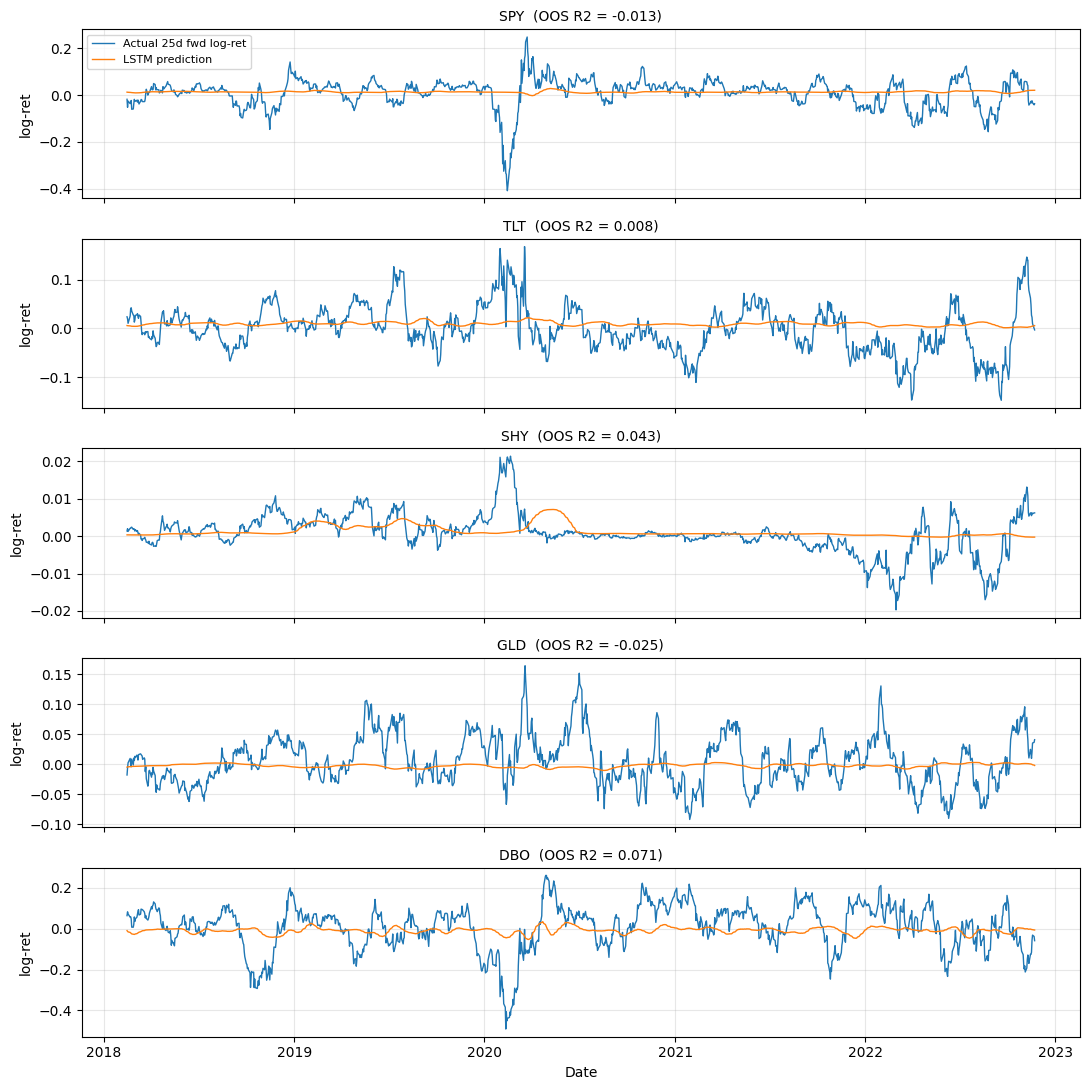

In [ ]:
# ============================================================
# Step 4 visual: predicted vs realised 25d return (one panel per ETF)
# ============================================================
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(11, 2.2*len(TICKERS)), sharex=True)
for ax, t in zip(np.atleast_1d(axes), TICKERS):
    d = single_data[t]
    ax.plot(d["test_dates"], d["y_test_true"], label="Actual 25d fwd log-ret", lw=1)
    ax.plot(single_pred[t].index, single_pred[t].values, label="LSTM prediction", lw=1)
    ax.set_title(f"{t}  (OOS R2 = {single_df.loc[t,'OOS_R2']:.3f})", fontsize=10)
    ax.grid(alpha=.3); ax.set_ylabel("log-ret")
axes[0].legend(loc="upper left", fontsize=8)
plt.xlabel("Date"); plt.tight_layout(); plt.show()


## Step 5 — Multi-output LSTM (cross-asset model)

We now build a single network whose input stacks the features of **all five ETFs** (5 assets × 3 features = 15 channels) over the same 30-day window, and whose output layer has **5 units** — one 25-day-ahead return per ETF. The same LSTM backbone feeds a `Dense(5)` head, so the shared recurrent layers can learn cross-asset dependencies that the isolated Step-4 models cannot see.

In [ ]:
# ============================================================
# Build the aligned multi-asset feature panel
# ============================================================
# Align all assets on common dates
common = feat[TICKERS[0]].index
for t in TICKERS[1:]:
    common = common.intersection(feat[t].index)

X_cols, Y_cols = [], []
panel = pd.DataFrame(index=common)
for t in TICKERS:
    for c in FEATURE_COLS:
        panel[f"{t}_{c}"] = feat[t].loc[common, c]; X_cols.append(f"{t}_{c}")
    panel[f"{t}_y"] = feat[t].loc[common, "y"];     Y_cols.append(f"{t}_y")
panel = panel.dropna()
print("Panel shape:", panel.shape, "| inputs:", len(X_cols), "| outputs:", len(Y_cols))


Panel shape: (3196, 20) | inputs: 15 | outputs: 5


In [ ]:
# ============================================================
# Split / scale / window the multi-output panel
# ============================================================
tr = panel[panel.index <  VAL_START]
va = panel[(panel.index >= VAL_START) & (panel.index < TEST_START)]
te = panel[panel.index >= TEST_START]

xs = MinMaxScaler((-1, 1)).fit(tr[X_cols])
ys = MinMaxScaler((-1, 1)).fit(tr[Y_cols])

def win_multi(part):
    Xv = xs.transform(part[X_cols]); Yv = ys.transform(part[Y_cols])
    X, Y = [], []
    for i in range(WINDOW, len(part)):
        X.append(Xv[i-WINDOW:i, :]); Y.append(Yv[i])
    return np.array(X), np.array(Y)

Xtr_m, Ytr_m = win_multi(tr)
Xva_m, Yva_m = win_multi(va)
Xte_m, Yte_m = win_multi(te)
test_dates_m = te.index[WINDOW:]
Yte_true     = te[Y_cols].values[WINDOW:]              # unscaled actual (n,5)
mean_train_Y = tr[Y_cols].mean().values                # per-asset benchmark
print("Xtr", Xtr_m.shape, "Ytr", Ytr_m.shape, "Xte", Xte_m.shape)


Xtr (1430, 30, 15) Ytr (1430, 5) Xte (1203, 30, 15)


In [ ]:
# ============================================================
# Multi-output LSTM (functional API, 5 linear outputs)
# ============================================================
def build_multi_lstm(n_features, n_outputs):
    inp = Input(shape=(WINDOW, n_features))
    x = LSTM(UNITS, return_sequences=True, activation="tanh")(inp)
    x = LSTM(UNITS, return_sequences=True, activation="tanh")(x); x = Dropout(DROPOUT, seed=SEED)(x)
    x = LSTM(UNITS, return_sequences=True, activation="tanh")(x); x = Dropout(DROPOUT, seed=SEED)(x)
    x = LSTM(UNITS, return_sequences=False, activation="tanh")(x); x = Dropout(DROPOUT, seed=SEED)(x)
    x = Dense(30, activation="relu")(x); x = Dropout(DROPOUT, seed=SEED)(x)
    x = Dense(15, activation="relu")(x); x = Dropout(DROPOUT, seed=SEED)(x)
    out = Dense(n_outputs)(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(LR), loss="mean_absolute_error")
    return m

tf.random.set_seed(SEED)
multi = build_multi_lstm(len(X_cols), len(Y_cols))
es = EarlyStopping(monitor="val_loss", mode="min", patience=8, restore_best_weights=True, verbose=0)
multi.fit(Xtr_m, Ytr_m, validation_data=(Xva_m, Yva_m),
          epochs=EPOCHS, batch_size=BATCH, verbose=0, callbacks=[es])
multi.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 30, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 30, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │            80 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,627 (889.17 KB)

 Trainable params: 75,875 (296.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 151,752 (592.79 KB)

In [ ]:
# ============================================================
# Multi-output: predictions & per-asset metrics, compared to Step 4
# ============================================================
pred_te_m = ys.inverse_transform(multi.predict(Xte_m, verbose=0))     # (n,5) unscaled
pred_tr_m = ys.inverse_transform(multi.predict(Xtr_m, verbose=0))
Ytr_true_m = ys.inverse_transform(Ytr_m)

multi_rows = []
for j, t in enumerate(TICKERS):
    multi_rows.append({
        "ETF": t,
        "IS_R2":      r2_campbell(Ytr_true_m[:, j], pred_tr_m[:, j], mean_train_Y[j]),
        "OOS_R2":     r2_campbell(Yte_true[:, j],   pred_te_m[:, j], mean_train_Y[j]),
        "OOS_RMSE":   rmse(Yte_true[:, j], pred_te_m[:, j]),
        "OOS_DirAcc": dir_acc(Yte_true[:, j], pred_te_m[:, j]),
    })
multi_df = pd.DataFrame(multi_rows).set_index("ETF")

compare = pd.concat({"Single (Step4)": single_df["OOS_R2"],
                     "Multi (Step5)":  multi_df["OOS_R2"]}, axis=1)
print("--- Step 5: multi-output results ---"); print(multi_df)
print("\n--- OOS R2 comparison ---"); compare


--- Step 5: multi-output results ---
     IS_R2  OOS_R2  OOS_RMSE  OOS_DirAcc
ETF                                     
SPY 0.1374  0.0139    0.0617      0.6924
TLT 0.1972 -0.1143    0.0511      0.4855
SHY 0.1766  0.0449    0.0051      0.5935
GLD 0.0923  0.0431    0.0404      0.5411
DBO 0.1577 -0.2093    0.1263      0.3807

--- OOS R2 comparison ---


,Single (Step4),Multi (Step5)
ETF,,
SPY,-0.0130,0.0139
TLT,0.0080,-0.1143
SHY,0.0432,0.0449
GLD,-0.0249,0.0431
DBO,0.0709,-0.2093


## Step 6 — Asset-allocation strategy & backtest

We turn the multi-output predictions into a **cross-sectional long/short strategy**, rebalanced every 25 trading days (non-overlapping, matching the forecast horizon):

- On each rebalance date, rank the 5 predicted 25-day returns.
- **Go long the top 2** assets (weight +1/2 each) and **short the bottom 2** (weight −1/2 each); the middle asset is flat. The book is dollar-neutral and uses information from all 5 forecasts.
- Realise each block with the actual 25-day forward simple return, then compound.

Benchmark: **buy-and-hold of an equally weighted (20% each) portfolio** of the 5 ETFs over the same test window.

In [ ]:
# ============================================================
# Backtest helper (non-overlapping 25-day blocks)
# ============================================================
def backtest(pred_matrix, dates):
    """pred_matrix: (n,5) predicted 25d log-rets aligned to `dates` (test set)."""
    pred = pd.DataFrame(pred_matrix, index=dates, columns=TICKERS)
    block_rets = []
    rebal_dates = []
    idx = list(range(0, len(pred) - HORIZON, HORIZON))   # non-overlapping
    for i in idx:
        d = pred.index[i]
        ranks = pred.iloc[i].sort_values()
        shorts = ranks.index[:2]; longs = ranks.index[-2:]
        w = pd.Series(0.0, index=TICKERS)
        w[longs] = 0.5; w[shorts] = -0.5
        # realised 25-day forward simple return per asset over the block
        fwd = np.exp((np.log(close[TICKERS]/close[TICKERS].shift(1))
                       .reindex(pred.index).iloc[i+1:i+1+HORIZON].sum())) - 1
        block_rets.append(float((w * fwd).sum()))
        rebal_dates.append(pred.index[min(i+HORIZON, len(pred)-1)])
    strat = pd.Series(block_rets, index=rebal_dates)
    strat_cum = (1 + strat).cumprod() - 1
    return strat, strat_cum

strat_ret, strat_cum = backtest(pred_te_m, test_dates_m)

# Equally weighted buy & hold over the test window
ew_daily = close[TICKERS].pct_change().reindex(test_dates_m).mean(axis=1).dropna()
ew_cum   = (1 + ew_daily).cumprod() - 1

print(f"Strategy total return  : {strat_cum.iloc[-1]*100:6.2f}%")
print(f"EW buy&hold total return: {ew_cum.iloc[-1]*100:6.2f}%")


Strategy total return  : -13.53%
EW buy&hold total return:  37.09%


In [ ]:
# ============================================================
# Performance statistics
# ============================================================
def perf_stats(period_rets, periods_per_year):
    r = np.asarray(period_rets, dtype=float)
    tot = np.prod(1 + r) - 1
    ann = (1 + tot) ** (periods_per_year / len(r)) - 1
    vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (r.mean() * periods_per_year) / vol if vol > 0 else np.nan
    cum = np.cumprod(1 + r); dd = (cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)
    return dict(Total=tot, Annualised=ann, Vol=vol, Sharpe=sharpe, MaxDD=dd.min())

stats = pd.DataFrame({
    "L/S strategy (25d)": perf_stats(strat_ret.values, 252/HORIZON),
    "EW buy & hold (daily)": perf_stats(ew_daily.values, 252),
}).T
stats


,Total,Annualised,Vol,Sharpe,MaxDD
L/S strategy (25d),-0.1353,-0.0301,0.2506,-0.0053,-0.5416
EW buy & hold (daily),0.3709,0.0683,0.1013,0.7030,-0.1678


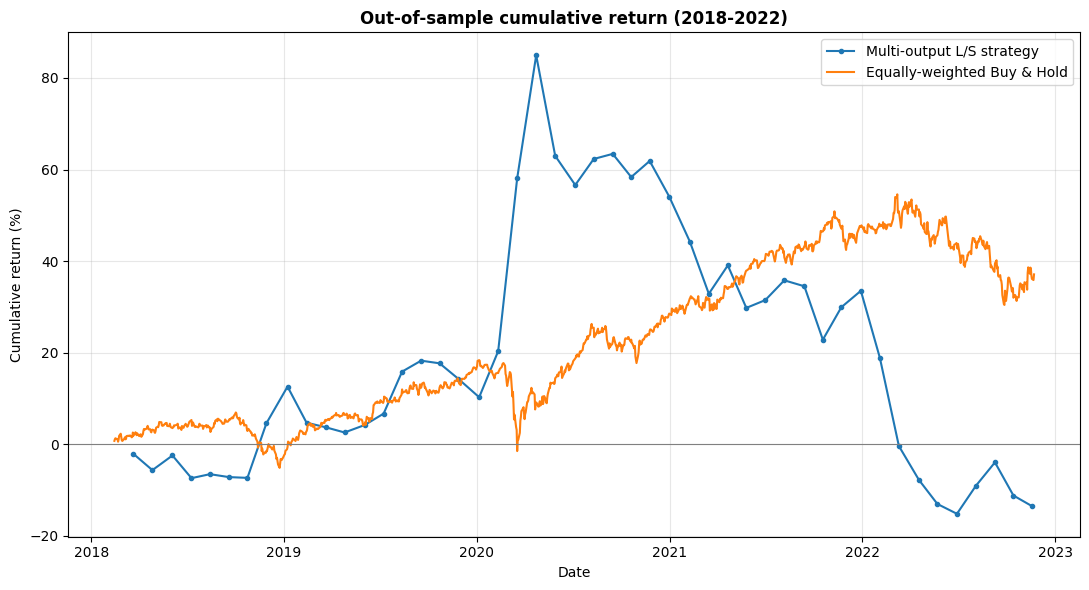

In [ ]:
# ============================================================
# Backtest plot
# ============================================================
plt.figure(figsize=(11, 6))
plt.plot(strat_cum.index, strat_cum.values*100, marker="o", ms=3,
         label="Multi-output L/S strategy")
plt.plot(ew_cum.index, ew_cum.values*100, label="Equally-weighted Buy & Hold")
plt.axhline(0, color="grey", lw=.8)
plt.title("Out-of-sample cumulative return (2018-2022)", fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Cumulative return (%)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


In [ ]:
pip install pyts

### Same strategy driven by the Step-4 single-output LSTMs
Running the identical ranking rule on the single-output predictions isolates the value added by the *multi-output* architecture from the value added by the LSTM itself.

Single-output L/S total return:  17.00%


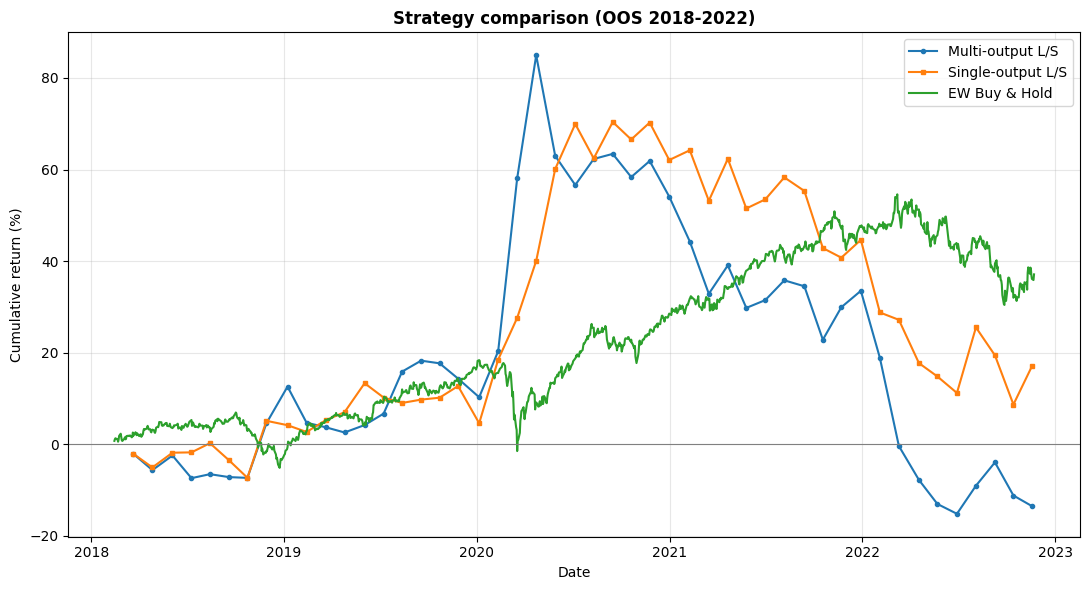

In [ ]:
# Assemble single-output predictions into the same (n,5) matrix on common test dates
single_mat = pd.concat([single_pred[t] for t in TICKERS], axis=1, keys=TICKERS).dropna()
s_dates = single_mat.index
strat_ret_s, strat_cum_s = backtest(single_mat.values, s_dates)
print(f"Single-output L/S total return: {strat_cum_s.iloc[-1]*100:6.2f}%")

plt.figure(figsize=(11,6))
plt.plot(strat_cum.index,  strat_cum.values*100,  marker="o", ms=3, label="Multi-output L/S")
plt.plot(strat_cum_s.index, strat_cum_s.values*100, marker="s", ms=3, label="Single-output L/S")
plt.plot(ew_cum.index, ew_cum.values*100, label="EW Buy & Hold")
plt.axhline(0, color="grey", lw=.8)
plt.title("Strategy comparison (OOS 2018-2022)", fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Cumulative return (%)"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()


**Comparsion of models using MSE and MAE**

In [18]:
import numpy as np, pandas as pd, yfinance as yf, seaborn as sns, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae
from statsmodels.tsa.stattools import adfuller
from tensorflow import keras
from keras import layers, models, callbacks, optimizers
from pyts.image import GramianAngularField

np.random.seed(50)
TICKERS, H, LAGS, SEQ = ["SPY","TLT","SHY","GLD","DBO"], 25, 60, 60
TRAIN_END, VAL_END, TEST_START = "2016-12-31", "2017-12-31", "2018-01-01"

prices = yf.download(TICKERS, "2010-01-01", "2022-12-30")["Close"].dropna()
rets = np.log(prices).diff().dropna()

# Helpers and Model Factory
def build_xy(df, win):
    v, idx = df.values, df.index
    return np.array([v[i-win:i] for i in range(win, len(v)-H)]), np.array([v[i+H] for i in range(win, len(v)-H)]), idx[win:len(v)-H]

def get_splits(idx):
    d = pd.to_datetime(idx)
    return d <= TRAIN_END, (d > TRAIN_END) & (d <= VAL_END), d >= TEST_START

def train_model(i_shape, layers_list, X, y, Xv, yv):
    inp = layers.Input(i_shape)
    x = inp
    for l in layers_list: x = l(x)
    m = models.Model(inp, x)
    m.compile(optimizers.Adam(1e-3), "mse")

    # Custom early stopping added here to halt training quickly if validation loss flattens
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        min_delta=1e-4,
        restore_best_weights=True
    )

    m.fit(
        X, y,
        validation_data=(Xv, yv),
        epochs=40,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1
    )
    return m


# Per-Asset Training
gaf = GramianAngularField(image_size=LAGS)
results = {m: {} for m in ["mlp", "cnn", "lstm"]}

for t in TICKERS:
    X, y, idx = build_xy(rets[t], LAGS)
    tr, va, te = get_splits(idx)
    Xs = StandardScaler().fit(X[tr]).transform(X).reshape(-1, LAGS, 1)
    Xi = gaf.fit_transform(X)[..., None]

    architectures = {
        "mlp": ((LAGS, 1), [layers.Flatten(), layers.Dense(128, "relu"), layers.Dense(64, "relu"), layers.Dense(1)], Xs),
        "cnn": ((LAGS, LAGS, 1), [layers.Conv2D(32, 3, activation="relu", padding="same"), layers.MaxPool2D(), layers.Conv2D(64, 3, activation="relu", padding="same"), layers.GlobalAvgPool2D(), layers.Dense(1)], Xi),
        "lstm": ((LAGS, 1), [layers.LSTM(64), layers.Dense(1)], Xs)
    }

    for name, (shape, arch, data) in architectures.items():
        m = train_model(shape, arch, data[tr], y[tr], data[va], y[va])
        yp = m.predict(data[te]).ravel()
        results[name][t] = (mse(y[te], yp), mae(y[te], yp))

/tmp/ipykernel_1022/3752420952.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(TICKERS, "2010-01-01", "2022-12-30")["Close"].dropna()
[*********************100%***********************]  5 of 5 completed


Epoch 1/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1103 - val_loss: 0.0102
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0286 - val_loss: 0.0078
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0161 - val_loss: 0.0066
Epoch 4/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106 - val_loss: 0.0061
Epoch 5/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0076 - val_loss: 0.0057
Epoch 6/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 7/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 - val_loss: 0.0053
Epoch 8/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0035 - val_loss: 0.0051
Epoch 9/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.0050
Epoch 10/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023 - val_loss: 0.0049
Epoch 11/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0018 - val_loss: 0.0048
Epoch 12/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0015 - 

Figure 4. Architecture Performance Table
           mlp                 cnn                lstm          
          MSE       MAE       MSE       MAE       MSE       MAE
SPY  0.042689  0.140431  0.000224  0.010879  0.000299  0.010816
TLT  0.028231  0.126494  0.000126  0.008305  0.000119  0.007959
SHY  0.050379  0.149648  0.000005  0.001803  0.000166  0.006510
GLD  0.013744  0.088099  0.000203  0.012048  0.000121  0.008242
DBO  0.036030  0.142971  0.000535  0.016324  0.000565  0.016830


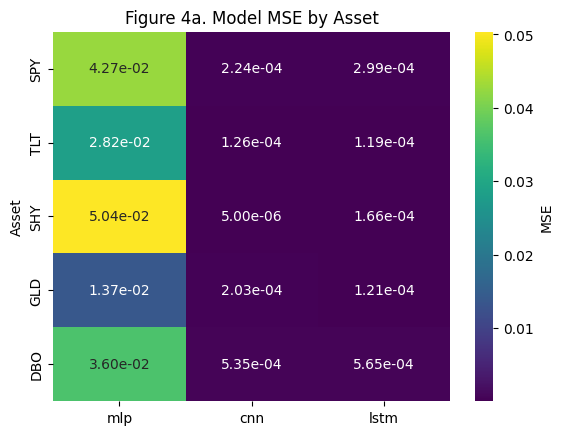

In [19]:
# Figure 4: Architecture performance table
df = pd.DataFrame({(m, k): {t: v[i] for t, v in results[m].items()} for m in results for i, k in enumerate(["MSE", "MAE"])}).round(6)
print("Figure 4. Architecture Performance Table\n", df)
sns.heatmap(df.xs("MSE", 1, 1), annot=True, fmt=".2e", cmap="viridis", cbar_kws={"label": "MSE"})
plt.title("Figure 4a. Model MSE by Asset"); plt.ylabel("Asset"); plt.show()